<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"></ul></div>

In [245]:
import requests
import lxml
import xmltodict
import re
from IPython.display import Image, display
from datetime import datetime
import dateutil.parser as dateparse
import pandas

In [255]:
url = "https://www.gdacs.org/xml/rss_7d.xml"

In [143]:
usgs_geojson_template = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/detail/{usgs_event_id}.geojson"

In [256]:
r = requests.get(url)
text = r.text

In [257]:
d = xmltodict.parse(text[3:])

In [258]:
d["rss"].keys()

odict_keys(['@version', '@xmlns:dc', '@xmlns:geo', '@xmlns:asgard', '@xmlns:gdacs', '@xmlns:glide', '@xmlns:georss', '@xmlns:atom', 'channel'])

In [259]:
d["rss"]["channel"]["pubDate"]

'Tue, 22 Mar 2022 12:57:01 GMT'

In [37]:
d["rss"]["channel"]["item"]

[OrderedDict([('title',
               'Green earthquake alert (Magnitude 4.8M, Depth:117.46km) in Vanuatu 22/03/2022 03:48 UTC, 100000 people within 100km.'),
              ('description',
               'On 3/22/2022 3:48:11 AM, an earthquake occurred in Vanuatu potentially affecting 100000 people within 100km. The earthquake had Magnitude 4.8M, Depth:117.46km.'),
              ('enclosure',
               OrderedDict([('@type', 'image/png'),
                            ('@length', '1'),
                            ('@url',
                             'https://www.gdacs.org/saved/gdacs/eq/eq1432723_1.png')])),
              ('gdacs:temporary', 'false'),
              ('link',
               'https://www.gdacs.org/report.aspx?eventtype=EQ&eventid=1314932'),
              ('pubDate', 'Tue, 22 Mar 2022 04:07:24 GMT'),
              ('gdacs:dateadded', 'Tue, 22 Mar 2022 04:07:24 GMT'),
              ('gdacs:datemodified', 'Tue, 22 Mar 2022 04:28:24 GMT'),
              ('gdacs:iscurrent

In [39]:
# with open(r"C:\Users\mbelambe\Desktop\Desktop\EventResponse\GDACS_RSS_feed.xml", "w") as f:
#     f.write(text[3:])

In [269]:
data = []
for i, item in enumerate(d["rss"]["channel"]["item"]):
    
    eventinstance_title = None
    eventinstance_description = None
    event_eventstartdate = None
    event_eventenddate = None
    eventsource_guid = None
    eventinstance_lat = None
    eventinstance_long = None
    eventsource_boundingbox = None
    event_eventtype = None
    eventmetrics_GDACSalertLevel = None
    eventmetrics_GDACSScore = None
    event_eventname = None
    eventsource_GDACS_EventID = None
    eventsource_GDACS_EpisodeID = None
    eventsource_GDACS_calculationtype = None
    eventmetrics_severity = None
    eventmetrics_severity_unit = None
    eventmetrics_severity_description = None
    eventmetrics_population = None
    eventmetrics_population_unit = None
    eventmetrics_population_description = None
    eventsource_rss_xml = None
    event_country = None
    usgs_url = None
    usgs_id = None
    usgs_data_url = None
    usgs_title = None
    usgs_technical_summary = None
    usgs_shape_url = None
    losspager = None
    usgs_pager_alertlevel = None
    usgs_pager_alertecon_png = None
    usgs_pager_alertfatalities_png = None
    usgs_pager_alertexposure_png = None
    usgs_pager_cities_url = None
    usgs_pager_cities_json = None
    data_item = {}
    eventinstance_title = item["title"]
    eventinstance_description = item["description"]
    event_eventstartdate = dateparse.parse(item["gdacs:fromdate"]).replace(tzinfo=None)
    event_eventenddate = dateparse.parse(item["gdacs:todate"]).replace(tzinfo=None)
    eventsource_guid = item["guid"]["#text"]
    eventinstance_lat = item["geo:Point"]["geo:lat"]
    eventinstance_long = item["geo:Point"]["geo:long"]
    eventsource_boundingbox = item["gdacs:bbox"]
    event_eventtype = item["gdacs:eventtype"]
    eventmetrics_GDACSalertLevel = item["gdacs:episodealertlevel"]
    eventmetrics_GDACSScore = item["gdacs:episodealertscore"]
    event_eventname = item["gdacs:eventname"]
    eventsource_GDACS_EventID = item["gdacs:eventid"]
    eventsource_GDACS_EpisodeID = item["gdacs:episodeid"]
    eventsource_GDACS_calculationtype = item["gdacs:calculationtype"]
    eventmetrics_severity = item["gdacs:severity"]["@value"]
    eventmetrics_severity_unit = item["gdacs:severity"]["@unit"]
    eventmetrics_severity_description = item["gdacs:severity"].get("#text", "")
    eventmetrics_population = item["gdacs:population"]["@value"]
    eventmetrics_population_unit = item["gdacs:population"]["@unit"]
    eventmetrics_population_description = item["gdacs:population"].get("#text", "")
    eventsource_rss_xml = item["gdacs:resources"]["gdacs:resource"]["@url"]
    event_country = item["gdacs:country"]
    
#     print(i, event_eventtype, eventsource_guid, event_eventname, event_country, event_eventstartdate, eventmetrics_severity_description, sep="|")
    if event_eventtype == "EQ":
        try:
            rss_xml_event = requests.get(eventsource_rss_xml).text
            rss_dict = xmltodict.parse(rss_xml_event[3:])

            usgs_url = [i for i in rss_dict["rss"]["channel"]["item"]["gdacs:resources"]["gdacs:resource"] if i["@id"] == "neic_json"][0]["@url"]
            usgs_id = re.findall(r"/([^./]+).json", usgs_url)[0]
            usgs_data_url = usgs_geojson_template.format(usgs_event_id=usgs_id)
            usgs_geojson = requests.get(usgs_data_url).json()
            usgs_title = usgs_geojson["properties"]["title"]
            general_text = usgs_geojson["properties"]["products"].get("general-text")
            usgs_technical_summary = ""
            if general_text:
                usgs_technical_summary = general_text[-1]["contents"][""]["bytes"]
            usgs_shape_url = None
            shakemap = usgs_geojson["properties"]["products"].get("shakemap")
            if shakemap:
                usgs_shape_url = shakemap[-1]["contents"]["download/shape.zip"]["url"]
            losspager = usgs_geojson["properties"]["products"].get("losspager")
            if losspager:
                losspager = losspager[-1]
                usgs_pager_alertlevel = losspager["properties"]["alertlevel"]
                usgs_pager_alertecon_png = losspager["contents"]["alertecon.png"]["url"]
                usgs_pager_alertfatalities_png = losspager["contents"]["alertfatal.png"]["url"]
                usgs_pager_alertexposure_png = losspager["contents"]["exposure.png"]["url"]
                usgs_pager_cities_url = losspager["contents"]["json/cities.json"]["url"]
                r = requests.get(usgs_pager_cities_url)
                j = r.json()
                usgs_pager_cities_json = j["onepager_cities"]
        except Exception as e:
            print(e.args)
            print(eventsource_rss_xml)
            if usgs_url:
                print(usgs_url,re.findall(r"/([^./]+).json", usgs_url))
            print(not losspager)
            print(not general_text)
            
    data.append({
"eventinstance_title": eventinstance_title,
"eventinstance_description": eventinstance_description,
"event_eventstartdate": event_eventstartdate,
"event_eventenddate": event_eventenddate,
"eventsource_guid": eventsource_guid,
"eventinstance_lat": eventinstance_lat,
"eventinstance_long": eventinstance_long,
"eventsource_boundingbox": eventsource_boundingbox,
"event_eventtype": event_eventtype,
"eventmetrics_GDACSalertLevel": eventmetrics_GDACSalertLevel,
"eventmetrics_GDACSScore": eventmetrics_GDACSScore,
"event_eventname": event_eventname,
"eventsource_GDACS_EventID": eventsource_GDACS_EventID,
"eventsource_GDACS_EpisodeID": eventsource_GDACS_EpisodeID,
"eventsource_GDACS_calculationtype": eventsource_GDACS_calculationtype,
"eventmetrics_severity": eventmetrics_severity,
"eventmetrics_severity_unit": eventmetrics_severity_unit,
"eventmetrics_severity_description": eventmetrics_severity_description,
"eventmetrics_population": eventmetrics_population,
"eventmetrics_population_unit": eventmetrics_population_unit,
"eventmetrics_population_description": eventmetrics_population_description,
"eventsource_rss_xml": eventsource_rss_xml,
"event_country": event_country,
"usgs_url": usgs_url,
"usgs_id": usgs_id,
"usgs_data_url": usgs_data_url,
"usgs_title": usgs_title,
"usgs_technical_summary": usgs_technical_summary,
"usgs_shape_url": usgs_shape_url,
"losspager": losspager,
"usgs_pager_alertlevel": usgs_pager_alertlevel,
"usgs_pager_alertecon_png": usgs_pager_alertecon_png,
"usgs_pager_alertfatalities_png": usgs_pager_alertfatalities_png,
"usgs_pager_alertexposure_png": usgs_pager_alertexposure_png,
"usgs_pager_cities_url": usgs_pager_cities_url,
"usgs_pager_cities_json": usgs_pager_cities_json,
})
#     break
df = pandas.DataFrame(data)
df.to_excel(r"C:\Users\mbelambe\Desktop\Desktop\EventResponse\data_0322.xlsx")

('list index out of range',)
https://www.gdacs.org//datareport/resources/EQ/1314686/rss_1314686.xml
True
True


In [265]:
df = pandas.DataFrame(data)

In [266]:
df.to_excel(r"C:\Users\mbelambe\Desktop\Desktop\EventResponse\data_0322.xlsx")

In [251]:
print(event_eventstartdate)
dateparse.parse(item["gdacs:fromdate"]).replace(tzinfo=None), dateparse.parse(item["gdacs:todate"]).replace(tzinfo=None)

2022-03-21 06:49:27+00:00


(datetime.datetime(2022, 3, 21, 6, 49, 27),
 datetime.datetime(2022, 3, 21, 6, 49, 27))

In [93]:
usgs_url = [i for i in rss_dict["rss"]["channel"]["item"]["gdacs:resources"]["gdacs:resource"] if i["@id"] == "neic_json"][0]["@url"]

In [102]:
usgs_id = re.findall(r"/([^./]+).json", usgs_url)[0]
usgs_id

'us6000h6kh'

In [97]:
usgs_url

'http://earthquake.usgs.gov/earthquakes/eventpage/us6000h6kh.json'

In [142]:
usgs_id = "us6000h519"

In [144]:
usgs_data_url = usgs_geojson_template.format(usgs_event_id=usgs_id)
usgs_data_url

'https://earthquake.usgs.gov/earthquakes/feed/v1.0/detail/us6000h519.geojson'

In [145]:
usgs_geojson = requests.get(usgs_data_url).json()

In [146]:
usgs_geojson

{'type': 'Feature',
 'properties': {'mag': 7.3,
  'place': '57 km ENE of Namie, Japan',
  'time': 1647441393264,
  'updated': 1647932783930,
  'tz': None,
  'url': 'https://earthquake.usgs.gov/earthquakes/eventpage/us6000h519',
  'felt': 351,
  'cdi': 8.6,
  'mmi': 8.008,
  'alert': 'orange',
  'status': 'reviewed',
  'tsunami': 1,
  'sig': 1302,
  'net': 'us',
  'code': '6000h519',
  'ids': ',pt22075004,us6000h519,at00r8udwu,',
  'sources': ',pt,us,at,',
  'types': ',dyfi,finite-fault,general-text,ground-failure,impact-link,losspager,moment-tensor,origin,phase-data,shakemap,',
  'nst': None,
  'dmin': 2.937,
  'rms': 1,
  'gap': 29,
  'magType': 'mww',
  'type': 'earthquake',
  'title': 'M 7.3 - 57 km ENE of Namie, Japan',
  'products': {'dyfi': [{'indexid': '1312802',
     'indexTime': 1647932786279,
     'id': 'urn:usgs-product:us:dyfi:us6000h519:1647932783930',
     'type': 'dyfi',
     'code': 'us6000h519',
     'source': 'us',
     'updateTime': 1647932783930,
     'status': 'UPD

In [176]:
usgs_geojson["properties"]["contents"]["general-text"]["properties"]["contents"]["bytes"]

KeyError: 'contents'

In [148]:
usgs_geojson["properties"].keys()

dict_keys(['mag', 'place', 'time', 'updated', 'tz', 'url', 'felt', 'cdi', 'mmi', 'alert', 'status', 'tsunami', 'sig', 'net', 'code', 'ids', 'sources', 'types', 'nst', 'dmin', 'rms', 'gap', 'magType', 'type', 'title', 'products'])

In [149]:
usgs_title = usgs_geojson["properties"]["title"]
usgs_geojson["properties"]["products"]

{'dyfi': [{'indexid': '1312802',
   'indexTime': 1647932786279,
   'id': 'urn:usgs-product:us:dyfi:us6000h519:1647932783930',
   'type': 'dyfi',
   'code': 'us6000h519',
   'source': 'us',
   'updateTime': 1647932783930,
   'status': 'UPDATE',
   'properties': {'depth': '63.07',
    'eventsource': 'us',
    'eventsourcecode': '6000h519',
    'eventtime': '2022-03-16T14:36:33.000Z',
    'latitude': '37.7015',
    'longitude': '141.587',
    'magnitude': '7.3',
    'maxmmi': '8.6',
    'num-responses': '351',
    'numResp': '351',
    'pdl-client-version': 'Version 2.7.10 2021-06-21'},
   'preferredWeight': 158,
   'contents': {'cdi_geo.txt': {'contentType': 'text/plain',
     'lastModified': 1647932783000,
     'length': 10180,
     'url': 'https://earthquake.usgs.gov/realtime/product/dyfi/us6000h519/us/1647932783930/cdi_geo.txt'},
    'cdi_geo.xml': {'contentType': 'application/xml',
     'lastModified': 1647932783000,
     'length': 34506,
     'url': 'https://earthquake.usgs.gov/real

In [192]:
usgs_geojson["properties"]["products"]["general-text"][-1]["contents"][""]["bytes"]

'<h1>Tectonic Summary</h1>\n<p>\nThe March 16, 2022, M 7.3 earthquake near the east coast of Honshu, Japan, occurred as the result of thrust faulting at or near the subduction zone plate boundary interface between the Pacific and North America plates. Moment tensor solutions indicate that slip occurred either on a moderately dipping fault striking to the south, or a moderately dipping fault striking to the north, consistent with the east-west oriented compression expected in this region. At the location of this earthquake, the Pacific plate moves approximately westward relative to the North America plate at a velocity of roughly 70 mm/yr, subducting beneath Japan at the Japan Trench and dipping to the west beneath Japan. Note that some researchers divide this region into several microplates that together define the relative motions among the larger Pacific, North America, and Eurasia plates; these include the Okhotsk and Amur microplates local to this earthquake that are part of North 

In [198]:
usgs_geojson["properties"]["products"]["shakemap"][-1].keys()

dict_keys(['indexid', 'indexTime', 'id', 'type', 'code', 'source', 'updateTime', 'status', 'properties', 'preferredWeight', 'contents'])

In [200]:
usgs_geojson["properties"]["products"]["shakemap"][-1]["contents"]

{'contents.xml': {'contentType': 'application/xml',
  'lastModified': 1647537943000,
  'length': 12211,
  'url': 'https://earthquake.usgs.gov/realtime/product/shakemap/us6000h519/us/1647537945901/contents.xml'},
 'download/attenuation_curves.json': {'contentType': 'application/json',
  'lastModified': 1647537928000,
  'length': 52789,
  'url': 'https://earthquake.usgs.gov/realtime/product/shakemap/us6000h519/us/1647537945901/download/attenuation_curves.json'},
 'download/cont_mi.json': {'contentType': 'application/json',
  'lastModified': 1647537501000,
  'length': 26298,
  'url': 'https://earthquake.usgs.gov/realtime/product/shakemap/us6000h519/us/1647537945901/download/cont_mi.json'},
 'download/cont_mmi.json': {'contentType': 'application/json',
  'lastModified': 1647537501000,
  'length': 26298,
  'url': 'https://earthquake.usgs.gov/realtime/product/shakemap/us6000h519/us/1647537945901/download/cont_mmi.json'},
 'download/cont_pga.json': {'contentType': 'application/json',
  'lastM

In [203]:
usgs_shape_url = usgs_geojson["properties"]["products"]["shakemap"][-1]["contents"]["download/shape.zip"]["url"]
usgs_shape_url

'https://earthquake.usgs.gov/realtime/product/shakemap/us6000h519/us/1647537945901/download/shape.zip'

In [154]:
losspager = usgs_geojson["properties"]["products"]["losspager"][-1]
losspager

{'indexid': '1296095',
 'indexTime': 1647539212029,
 'id': 'urn:usgs-product:us:losspager:us6000h519:1647538196079',
 'type': 'losspager',
 'code': 'us6000h519',
 'source': 'us',
 'updateTime': 1647538196079,
 'status': 'UPDATE',
 'properties': {'alertlevel': 'orange',
  'depth': '63.1',
  'eventsource': 'us',
  'eventsourcecode': '6000h519',
  'eventtime': '2022-03-16T14:36:33.000Z',
  'latitude': '37.7015',
  'longitude': '141.5870',
  'magnitude': '7.3',
  'maxmmi': '8',
  'pdl-client-version': 'Version 2.7.9 2021-02-10',
  'review-status': 'automatic'},
 'preferredWeight': 158,
 'contents': {'alertecon.pdf': {'contentType': 'application/pdf',
   'lastModified': 1647538064000,
   'length': 11337,
   'url': 'https://earthquake.usgs.gov/realtime/product/losspager/us6000h519/us/1647538196079/alertecon.pdf'},
  'alertecon.png': {'contentType': 'image/png',
   'lastModified': 1647538064000,
   'length': 15513,
   'url': 'https://earthquake.usgs.gov/realtime/product/losspager/us6000h519/u

orange


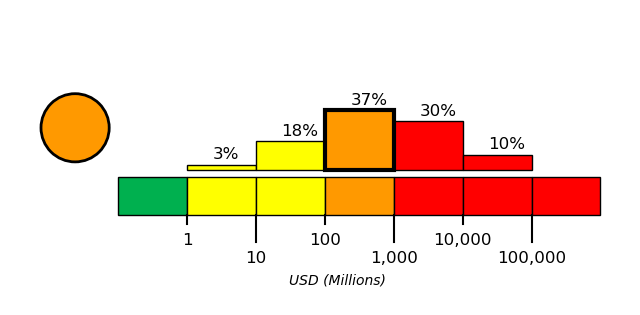

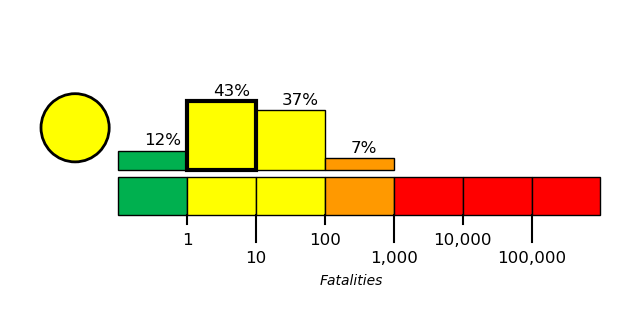

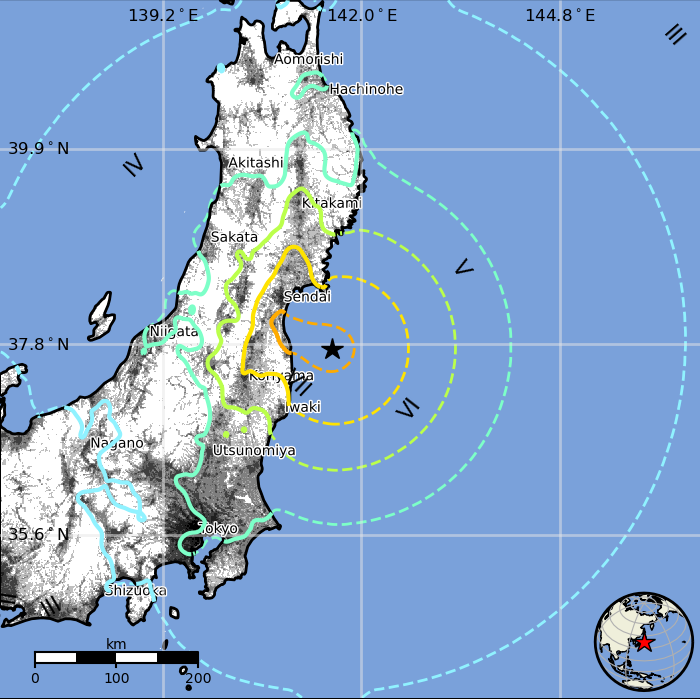

In [204]:
print(losspager["properties"]["alertlevel"])
display(Image(losspager["contents"]["alertecon.png"]["url"]))
display(Image(losspager["contents"]["alertfatal.png"]["url"]))
display(Image(losspager["contents"]["exposure.png"]["url"]))

In [210]:
# r = requests.get('https://earthquake.usgs.gov/realtime/product/losspager/us6000h519/us/1647538196079/json/losses.json')
# r = requests.get('https://earthquake.usgs.gov/realtime/product/losspager/us6000h519/us/1647538196079/json/historical_earthquakes.json')
# url = "https://earthquake.usgs.gov/realtime/product/losspager/us6000h519/us/1647538196079/json/exposures.json"
# url = 'https://earthquake.usgs.gov/realtime/product/losspager/us6000h519/us/1647538196079/json/alerts.json'
url = 'https://earthquake.usgs.gov/realtime/product/losspager/us6000h519/us/1647538196079/json/cities.json'
cities_url = losspager["contents"]["json/cities.json"]["url"]
r = requests.get(cities_url)
j = r.json()
j["onepager_cities"]

[{'name': 'Kakuda',
  'ccode': 'JP',
  'lat': 37.97451,
  'lon': 140.77202,
  'iscap': False,
  'pop': 33221,
  'mmi': 7.7062803434,
  'on_map': 0.0},
 {'name': 'Watari',
  'ccode': 'JP',
  'lat': 38.035,
  'lon': 140.85111,
  'iscap': False,
  'pop': 36321,
  'mmi': 7.6999998093,
  'on_map': 0.0},
 {'name': 'Marumori',
  'ccode': 'JP',
  'lat': 37.91667,
  'lon': 140.76667,
  'iscap': False,
  'pop': 16752,
  'mmi': 7.6438413934,
  'on_map': 0.0},
 {'name': 'Iwanuma',
  'ccode': 'JP',
  'lat': 38.10472,
  'lon': 140.85944,
  'iscap': False,
  'pop': 42411,
  'mmi': 7.5999999046,
  'on_map': 0.0},
 {'name': 'Okawara',
  'ccode': 'JP',
  'lat': 38.05,
  'lon': 140.73361,
  'iscap': False,
  'pop': 23340,
  'mmi': 7.4062807411,
  'on_map': 0.0},
 {'name': 'Namie',
  'ccode': 'JP',
  'lat': 37.48333,
  'lon': 141.0,
  'iscap': False,
  'pop': 21866,
  'mmi': 7.2812794288,
  'on_map': 0.0},
 {'name': 'Sendai',
  'ccode': 'JP',
  'lat': 38.26667,
  'lon': 140.86667,
  'iscap': True,
  'pop'